# Dark-matter substructure classification with AstroLens Lensiformer

A tutorial-scale training example for `astrolens.models.lensiformer.Lensiformer`
(Velôso, Toomey & Gleyzer, NeurIPS ML4PS 2023,
https://ml4physicalsciences.github.io/2023/files/NeurIPS_ML4PS_2023_214.pdf),
a physics-informed Vision Transformer that classifies the dark-matter
substructure (no substructure / CDM / axion) responsible for a strong
gravitational lensing image.

Trains on the canonical ML4SCI "Common Test I" lensing benchmark (150x150,
single-channel, 3 balanced classes) from
[`mwt5345/DeepLenseSim`](https://github.com/mwt5345/DeepLenseSim/tree/main/Model_I).
That repository's own Google Drive links are dead, so this notebook instead
loads a verified re-upload,
[`nelm/gsoc-2026-deeplense-dataset`](https://huggingface.co/datasets/nelm/gsoc-2026-deeplense-dataset)
on Hugging Face — see `utils/deeplense.py`.

Model size and epoch count are reduced from the paper's ~11M-parameter,
300-epoch A100 benchmark to fit one notebook session.

## Install example-only dependencies

Not part of AstroLens' core install (`requirements.txt`) — only needed for this example.

In [1]:
!pip install -q huggingface_hub scikit-learn matplotlib torchvision

## Imports

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

import astrolens
from utils import deeplense
from utils.gz10 import run_classification_epoch  # dataset-agnostic train/eval loop

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load the dataset

Subsampled from the full 10,000/2,500 images per class to keep this a
tutorial-scale run; `utils.deeplense` extracts only the `.npy` members it
needs from the source zip, not the full 6.5 GB archive. The source only
ships a train/val split (no held-out test), so the val split doubles as
this notebook's evaluation set.

In [3]:
IMG_SIZE = 150
BATCH_SIZE = 64
NUM_WORKERS = 4
MAX_TRAIN_PER_CLASS = 10000
MAX_VAL_PER_CLASS = 2500
CLASS_NAMES = deeplense.CLASS_NAMES  # no substructure / CDM (sphere) / axion (vort)
NUM_CLASSES = deeplense.NUM_CLASSES
DATA_ROOT = "data/deeplense"

normalize = transforms.Normalize((deeplense.IMAGE_MEAN,), (deeplense.IMAGE_STD,))
train_dataset = deeplense.LensingDataset(DATA_ROOT, "train", MAX_TRAIN_PER_CLASS, transform=normalize)
val_dataset = deeplense.LensingDataset(DATA_ROOT, "val", MAX_VAL_PER_CLASS, transform=normalize)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
    num_workers=NUM_WORKERS, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, 
    num_workers=NUM_WORKERS, persistent_workers=True
)

len(train_dataset), len(val_dataset)

(30000, 7500)

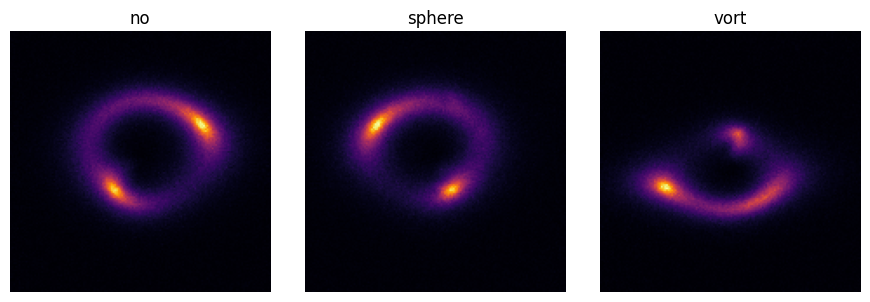

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
seen = set()
for image, label in train_dataset:
    if label in seen:
        continue
    raw = image * deeplense.IMAGE_STD + deeplense.IMAGE_MEAN
    axes[label].imshow(raw.squeeze(0), cmap="inferno")
    axes[label].set_title(CLASS_NAMES[label])
    axes[label].axis("off")
    seen.add(label)
    if len(seen) == NUM_CLASSES:
        break
fig.tight_layout()

## Create the model

`patch_size=15` on a 150x150 image gives a 10x10 patch grid. The physics-informed
encoder's `k_min`/`k_max` and `pixel_scale` keep their defaults, which follow the
reference implementation's HST-like arcsec/pixel scale and Einstein-radius-like
deflection bounds directly (`PhysicsInformedEncoder`/`Physics` in the reference's
`components/`), rather than an invented rescaling. Model width (`embed_dim=96`,
3 encoder + 3 decoder blocks) is reduced from the paper's ~11M-parameter
benchmark configuration to train quickly in a notebook.

In [5]:
model = astrolens.create_model(
    "lensiformer",
    img_size=IMG_SIZE,
    in_chans=1,
    num_classes=NUM_CLASSES,
    patch_size=15,
    embed_dim=96,
    num_heads=6,
    encoder_depth=3,
    decoder_depth=3,
).to(device)

sum(p.numel() for p in model.parameters())

1072714

## Train

`AdamW` and `ReduceLROnPlateau` follow the paper's optimizer choice and its
"halve the learning rate after 10 epochs without improvement" schedule,
shortened to a `patience` of 3 for this reduced run. The source dataset is
class-balanced, so `deeplense.class_weights` has little effect here — kept
for parity with the other training examples.

In [6]:
MAX_EPOCHS = 30
LR = 1e-3

criterion = nn.CrossEntropyLoss(weight=deeplense.class_weights(train_dataset).to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

progress = tqdm(range(1, MAX_EPOCHS + 1), unit="epoch")
for epoch in progress:
    train_loss, train_acc = run_classification_epoch(
        model, train_loader, criterion, device, train=True, optimizer=optimizer
    )
    val_loss, val_acc = run_classification_epoch(model, val_loader, criterion, device, train=False)
    scheduler.step(val_loss)
    progress.set_postfix(
        train_loss=f"{train_loss:.3f}",
        train_acc=f"{train_acc:.3f}",
        val_loss=f"{val_loss:.3f}",
        val_acc=f"{val_acc:.3f}",
        lr=f"{optimizer.param_groups[0]['lr']:.1e}",
    )

  0%|          | 0/30 [00:00<?, ?epoch/s]

## Evaluate on the held-out val split

In [7]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images.to(device))
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())
        y_true.extend(labels.tolist())

val_acc = accuracy_score(y_true, y_pred)
val_f1_macro = f1_score(y_true, y_pred, average="macro")
print(f"val_acc={val_acc:.3f} val_f1_macro={val_f1_macro:.3f}\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

val_acc=0.500 val_f1_macro=0.505

              precision    recall  f1-score   support

          no       0.55      0.47      0.51      2500
      sphere       0.38      0.49      0.43      2500
        vort       0.62      0.54      0.58      2500

    accuracy                           0.50      7500
   macro avg       0.52      0.50      0.50      7500
weighted avg       0.52      0.50      0.50      7500



## Inspect the physics-informed source reconstruction

`Lensiformer.reconstruct_source` warps each observed image through the
lens equation using the encoder's learned Singular-Isothermal-Sphere scale
field — the intermediate the decoder actually attends to, not just a
diagnostic. Comparing it to the input shows the ring-shaped lensing
distortion being partially undone.

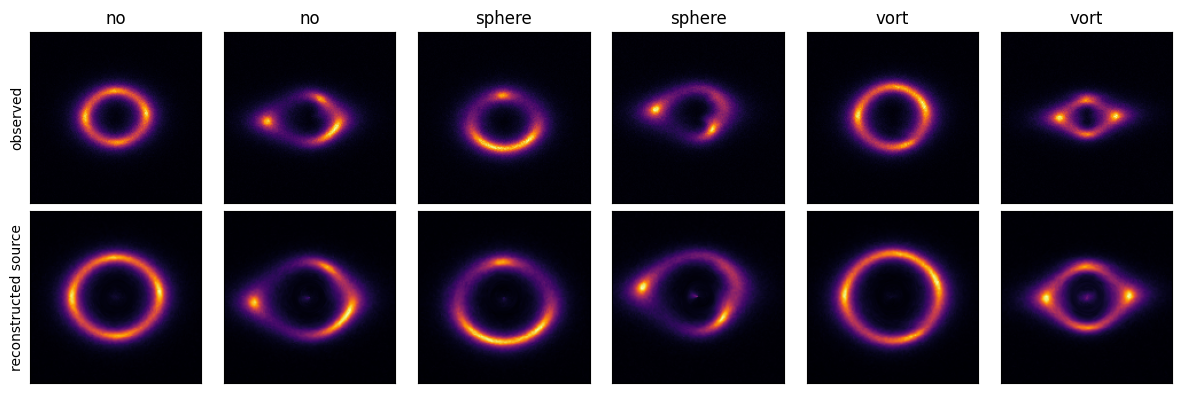

In [8]:
samples = []
seen = {name: 0 for name in CLASS_NAMES}
for image, label in val_dataset:
    if seen[CLASS_NAMES[label]] >= 2:
        continue
    samples.append((image, label))
    seen[CLASS_NAMES[label]] += 1
    if len(samples) == 6:
        break

images = torch.stack([s[0] for s in samples])
labels = [s[1] for s in samples]
with torch.no_grad():
    sources = model.reconstruct_source(images.to(device)).cpu()

raw_images = images * deeplense.IMAGE_STD + deeplense.IMAGE_MEAN
raw_sources = sources * deeplense.IMAGE_STD + deeplense.IMAGE_MEAN

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(raw_images[i, 0], cmap="inferno")
    axes[0, i].set_title(CLASS_NAMES[labels[i]])
    axes[1, i].imshow(raw_sources[i, 0], cmap="inferno")
    for row in (0, 1):
        axes[row, i].set_xticks([])
        axes[row, i].set_yticks([])
axes[0, 0].set_ylabel("observed")
axes[1, 0].set_ylabel("reconstructed source")
fig.tight_layout()